# Projet de Statistique Appliquée

## Étude comparative de l'efficacité des hôpitaux selon leur statut

Projet d'économétrie appliqué s'appuyant sur les données publiques de la Statistique Annuelle des Établissements (SAE) et d'Hospidiag.

In [8]:
%pip install linearmodels
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


### 1 - Importation des bibliothèques

In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.iv import IV2SLS
from scipy import stats

### 2 - Importations des données

Extraction des Outputs et Inputs de 2022, dans un premiers temps on s'intéresse aux services d'Urgence, de Médecine, Chirurgie et obstétrique (MCO), Soins de suite et rééducation (SSR), Psychiatrie, Unité de soins de longue durée (USLD), et séances (séances de dyalise, de chimiothérapie, etc).

In [10]:
SYGEN2022 = pd.read_csv("SAE/2022/SYGEN_2022r.csv", sep=";", encoding="latin-1")
Data = SYGEN2022[['FI','FI_EJ','EFFSAL_TOT','EFFLIB_TOT','EFF_INFSANSSPE','EFF_INFAVECSPE','EFF_AID','EFF_DIR','EFF_DIRSOI','EFF_AUTADM','SEJHC_SSR','SEJHC_MCO','SEJHP_MCO','SEJ_HTP_TOT','VEN_HDJ_TOT','VEN_HDN_TOT','SEAN_HEMO_CENTRE','SEAN_CHIMIO','SEAN_RADIO']]

On extrait le statut des différents établissement depuis le fichier FINESS.xlsx obtenu sur le site SAE diffusion.
On crée une distinction entre les hôpitaux publics classiques qui serviront par la suite de référence et les grands hôpitaux publics, les CHU, en ajoutant une catégorie 'CHU' dans la colonne 'Statut'

In [11]:
FINESS = pd.read_excel("finess.xlsx")
FINESS = FINESS.rename(columns={"FINESS":"FI","Statut Juridique":"Statut"})

CHU = pd.read_excel("CHRU.xlsx")
CHU["FINESS"] = CHU["FINESS"].astype(object)

FINESS.loc[FINESS['Raison sociale'].isin(CHU['Raison sociale']), "Statut"] = "CHU"  #Ajout du statut CHU dans la colonne Statut de FINESS
FINESS = FINESS.drop(FINESS.columns[[1,2,4]],axis=1)  #supression des colonnes inutiles

Data = Data.merge(FINESS, on="FI", how="left")

In [12]:
print(Data.shape)
print(SYGEN2022.shape)

(3988, 20)
(3988, 208)


Extraction des données Hospidiag 2022 :

In [13]:
hd2022 = pd.read_csv("Hospidiag/hd2022.csv", sep=";", decimal = ",", encoding="utf-8")

Ajout des output des services d'urgences (nombre de passages) :

In [14]:
Urg2022 = pd.read_csv("SAE/2022/URGENCES2_2022r.csv", sep=";", encoding="latin-1")
Urg2022 = Urg2022[['FI','PASSU']]
Urg2022 = Urg2022.groupby("FI").sum().reset_index()  # Agrégation des données d'urgences par établissement
Data = Data.merge(Urg2022, on="FI", how="left")

Ajout des entrées au unités de soins longue durée (USLD) :

In [15]:
USLD2022 = pd.read_csv("SAE/2022/USLD_2022r.csv", sep=";", encoding="latin-1")
USLD2022 = USLD2022[['FI','ENT']]
Data = Data.merge(USLD2022, on="FI", how="left")

### 3 - Constructions des variables de la régression

#### 3.1 - Intputs

Total médecins (libéraux et saliariés confondus) : 

In [16]:
Data['EFF_MED'] = Data['EFFSAL_TOT'] + Data['EFFLIB_TOT'].fillna(0)
Data['EFF_MED'].describe()

count    3332.000000
mean       48.876351
std       102.023147
min         0.000000
25%         4.000000
50%        10.000000
75%        48.000000
max      1515.000000
Name: EFF_MED, dtype: float64

Total infirmiers (spécialisés et non-spécialisés) : 

In [17]:
Data['EFF_IDE'] = Data['EFF_INFSANSSPE'] + Data['EFF_INFAVECSPE'].fillna(0)
Data['EFF_IDE'].describe()

count    3530.000000
mean       97.522946
std       204.341642
min         0.000000
25%        11.000000
50%        24.000000
75%        75.000000
max      2090.000000
Name: EFF_IDE, dtype: float64

Total personnel administratif :

In [18]:
Data['EFF_ADMIN'] = Data['EFF_AUTADM'] + Data['EFF_DIRSOI'].fillna(0) + Data['EFF_DIR'].fillna(0)
Data["EFF_ADMIN"].describe()

count    3389.000000
mean       46.102980
std        88.991979
min         0.000000
25%         7.000000
50%        14.000000
75%        40.000000
max       952.000000
Name: EFF_ADMIN, dtype: float64

In [19]:
Data['EFF_DIR'].describe()

count    2616.000000
mean        3.435015
std         3.889435
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        64.000000
Name: EFF_DIR, dtype: float64

NB : la colonne 'EFF_DIRSOI' comptabilisant les effectifs de directeurs de soins par établissements n'a que 1050 lignes renseignées, sa prise en compte fait passer l'effectif moyen en personnel administratif de 62 à 63, l'influence de cette catégorie de personnel peut donc sans doute être considéré comme mineure.

#### 3.2 - Outputs

Total séjours MCO (hospitalisation partielle et complète confondu) :

In [20]:
Data['MCO'] = Data['SEJHP_MCO'] + Data['SEJHC_MCO']
Data['MCO'] = Data['MCO'].fillna(0)
Data['I_MCO'] = (Data['MCO'] > 0).astype(int)

Total séjours en psychiatrie (hospitalisations complètes, venues de jour et venues de nuit) :

In [21]:
Data['PSY'] = Data['SEJ_HTP_TOT'] + Data['VEN_HDJ_TOT'].fillna(0) + Data['VEN_HDN_TOT'].fillna(0)
Data['PSY'].describe()

count      512.000000
mean      7518.765625
std       7778.889299
min          0.000000
25%       1740.250000
50%       5311.000000
75%      10591.750000
max      47168.000000
Name: PSY, dtype: float64

In [22]:
Data['PSY'] = Data['PSY'].fillna(0)
Data['I_PSY'] = (Data['PSY'] > 0).astype(int)

In [23]:
Data["SEANCES"] = Data['SEAN_HEMO_CENTRE'].fillna(0) + Data['SEAN_CHIMIO'] + Data['SEAN_RADIO'].fillna(0)
Data["SEANCES"].describe()

count      728.000000
mean     10178.453297
std      15332.803292
min          0.000000
25%        573.000000
50%       3123.500000
75%      13299.250000
max      81352.000000
Name: SEANCES, dtype: float64

In [24]:
Data['SEANCES'] = Data['SEANCES'].fillna(0)
Data['I_SEANCES'] = (Data['SEANCES'] > 0).astype(int)

In [25]:
Data['PASSU'].describe()

count       623.000000
mean      34725.581059
std       24722.086305
min         314.000000
25%       16610.000000
50%       26651.000000
75%       46619.000000
max      132443.000000
Name: PASSU, dtype: float64

In [26]:
Data['PASSU'] = Data['PASSU'].fillna(0)
Data['I_URG'] = (Data['PASSU'] > 0).astype(int)

In [27]:
Data['PASSU'][Data['PASSU'] > 0]

0       42384.0
1       16727.0
13      22583.0
23      23369.0
24      38727.0
         ...   
3922    49067.0
3923    66717.0
3924    50064.0
3925    31213.0
3982    49595.0
Name: PASSU, Length: 623, dtype: float64

In [28]:
Data['ENT'].describe()

count    577.000000
mean      29.668977
std       21.068744
min        0.000000
25%       17.000000
50%       24.000000
75%       37.000000
max      167.000000
Name: ENT, dtype: float64

In [29]:
Data['ENT'] = Data['ENT'].fillna(0)
Data['I_USLD'] = (Data['ENT'] > 0).astype(int)

In [30]:
Data["SEJHC_SSR"].describe()

count    1802.000000
mean      474.011654
std       379.674641
min         0.000000
25%       220.000000
50%       377.000000
75%       633.750000
max      2755.000000
Name: SEJHC_SSR, dtype: float64

In [31]:
Data['SEJHC_SSR'] = Data['SEJHC_SSR'].fillna(0)
Data['I_SSR'] = (Data['SEJHC_SSR'] > 0).astype(int)

#### 3.3 - Passage au log

Passage des variables d'intérêt en log (En ajoutant +1 pour éviter des valeurs négatives/-infini) :

In [32]:
Data["lURG"] = np.log(Data["PASSU"]+1)
Data["lMCO_HC"] = np.log(SYGEN2022["SEJHC_MCO"].fillna(0)+1)
Data["lMCO_HP"] = np.log(SYGEN2022["SEJHP_MCO"].fillna(0)+1)
Data["lPSY"] = np.log(Data["PSY"]+1)
Data["lSSR"] = np.log(Data["SEJHC_SSR"]+1)
Data["lSEANCES"] = np.log(Data["SEANCES"]+1)
Data['lUSLD'] = np.log(Data['ENT']+1)

Data["lMED"] = np.log(Data["EFF_MED"]+1)
Data["lIDE"] = np.log(Data["EFF_IDE"]+1)
Data["lAID"] = np.log(Data["EFF_AID"]+1)
Data["lADMIN"] = np.log(Data["EFF_ADMIN"]+1)

#### 3.4 - Ajout de variables de contrôles

On construit deux variables de contrôle : Statut_PNL (resp. Statut_PL) vaut 1 si l'établissement est privé non lucratif (resp. privé lucratif) 

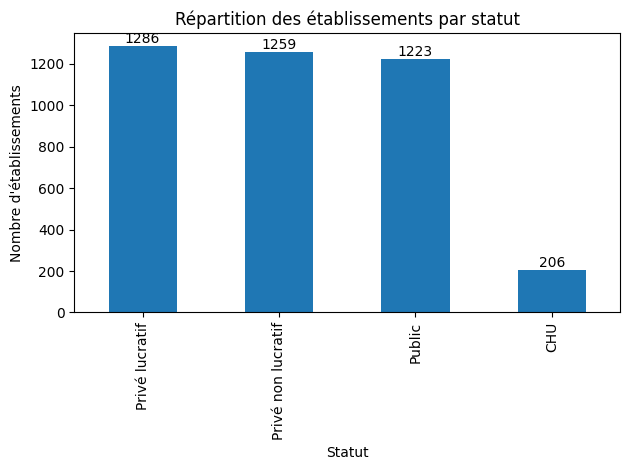

In [33]:
counts = FINESS["Statut"].value_counts()
ax = counts.plot(kind="bar")

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

plt.title("Répartition des établissements par statut")
plt.xlabel("Statut")
plt.ylabel("Nombre d'établissements")

plt.tight_layout()
plt.show()

In [34]:
dummies = pd.get_dummies(Data["Statut"], prefix="Statut")

Data["Statut_PNL"] = dummies["Statut_Privé non lucratif"]
Data["Statut_PL"]  = dummies["Statut_Privé lucratif"]
Data["Statut_CHU"] = dummies["Statut_CHU"]

Data["Statut_PNL"] = Data["Statut_PNL"].astype(int)
Data["Statut_PL"]  = Data["Statut_PL"].astype(int)
Data["Statut_CHU"] = Data["Statut_CHU"].astype(int)

Catégorisation des variables :

In [35]:
inputs = ["lMED", "lIDE", "lAID", "lADMIN"]
outputs = ["lURG", "lMCO_HP","lMCO_HC", "lSSR", "lPSY","lSEANCES", "lUSLD"]
controles_statut = ["Statut_PNL", "Statut_PL","Statut_CHU"] 
controles_services = ["I_PSY", "I_SSR", "I_URG", "I_USLD","I_SEANCES", "I_MCO"]
controles_autres= ["lduree_MCO"]
controles_hospidiag = ["A9_imp_2022"]
interactions_statut = [f"{var}_PNL" for var in outputs] + [f"{var}_PL" for var in outputs] + [f"{var}_CHU" for var in outputs]

Ajout de variables d'outputs liées aux différentes catégories d'établissement contrôlées ("termes d'interaction") :

In [36]:
for var in outputs:
    Data[f"{var}_PNL"] = Data[var] * Data["Statut_PNL"]
    Data[f"{var}_PL"]  = Data[var] * Data["Statut_PL"]
    Data[f"{var}_CHU"]  = Data[var] * Data["Statut_CHU"]

Pour mieux mesurer le gain d'efficacité lié à la réduction de la durée des séjours, on construit la variable "lduree_MCO" contient la durée moyenne d'un séjour en hospitalisation complète en log.

In [37]:
Data["duree_MCO"] = SYGEN2022['JOU_MCO']/SYGEN2022['SEJHC_MCO']
Data["duree_MCO"] = Data["duree_MCO"].fillna(0)
Data["lduree_MCO"] = np.log(Data["duree_MCO"]+1)

On souhaite également contrôler pour la gravité des cas, pour cela on utilise l'indicateur A9 d'Hospidiag

Ajout des valeurs imputées de l'indicateur de gravité A9 d'hospidiag : 

In [38]:
A9_imputed = pd.read_csv("A9_imputed2022.csv", sep=",", decimal = ".", encoding="utf-8")
A9_imputed

,FI,A9_imp_2022
0,010000024,11.360
1,010000032,18.320
2,010000065,54.820
3,010000081,12.920
4,010000099,59.410
...,...,...
3983,980500763,0.000
3984,980500920,12.868
3985,980501159,13.474
3986,980501258,13.474


In [39]:
Data = Data.merge(A9_imputed, on="FI", how="left")

### 4 - Première approche : régression linéaire en contrôlant pour le statut

#### 4.1 - Estimation des coefficients de la demande conditionnelle

Préparation des données à la régression : 

In [40]:
X_vars = (outputs + controles_statut + controles_services + controles_autres + interactions_statut)

Estimation des coefficients : On régresse les inputs (médecins, infirmiers, aides soignantes, personnel adminisitratif) sur les outputs et les contrôles

In [41]:
results = {}
dict_diff = {}

In [42]:
for inp in inputs:
    Data_clean = Data[[inp]+X_vars].copy()
    Data_clean = Data_clean.apply(pd.to_numeric, errors="coerce")
    Data_clean = Data_clean.dropna()
    
    y = Data_clean[inp]

    X = Data_clean[X_vars]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results[inp] = model

In [43]:
for inp, model in results.items():
    for statut in ["PNL", "PL", "CHU"]:
        coef_name = f"Statut_{statut}"

        if coef_name in model.params.index:
            coef = model.params[coef_name]
            pct = (np.exp(coef) - 1) * 100
            dict_diff[(inp, statut)] = pct

#### 4.2 - Résultats

In [44]:
dict_diff

{('lMED', 'PNL'): np.float64(-6.40427927859728),
 ('lMED', 'PL'): np.float64(25.13335890149562),
 ('lMED', 'CHU'): np.float64(27.919924958119815),
 ('lIDE', 'PNL'): np.float64(-30.168207522464474),
 ('lIDE', 'PL'): np.float64(-31.839269382217715),
 ('lIDE', 'CHU'): np.float64(133.08062148554325),
 ('lAID', 'PNL'): np.float64(-45.30269289155881),
 ('lAID', 'PL'): np.float64(-43.98585214469494),
 ('lAID', 'CHU'): np.float64(111.89839743711802),
 ('lADMIN', 'PNL'): np.float64(12.25607789334271),
 ('lADMIN', 'PL'): np.float64(2.0300194320682863),
 ('lADMIN', 'CHU'): np.float64(-0.7479402930581691)}

|    |    Privé Lucratif     |   Privé non lucratif    |    CHU   |
|:----------|------------:|-------------:|-------------:|
| Personnel administratif    |      +4.1% |        +28.8% |    +6.3%     |
| Aides-soigant.e.s      |      -45.9% |     -43.9%  |      +87.2%   |
| Infirmièr.e.s      |      -11.3% |       -6.2% |    +161.5%      |
| Médecins      |      +14.5% |     +21.4%    |       +54%  |

Tableau regroupant les différences d'emploi des différentes catégories de personnel à niveau de production égal selon la nature de l'etablissement (privé non lucratif,privé lucratif ou CHU) en prenant comme référence les hopitaux publics petits ou moyens (non CHU).

Contrôles : présence de service d'urgence, de MCO, de psychiatrie, de SSR, d'USLD, et de séances ; durée moyenne de séjour en MCO

Contrôles à rajouter : indice de recherche/enseignement (hospidiag), indice de gravité A9 d'hospidiag

/!\ les résultats ne sont pas statistiquement significatifs pour le personnel administratif (cf pvalues)

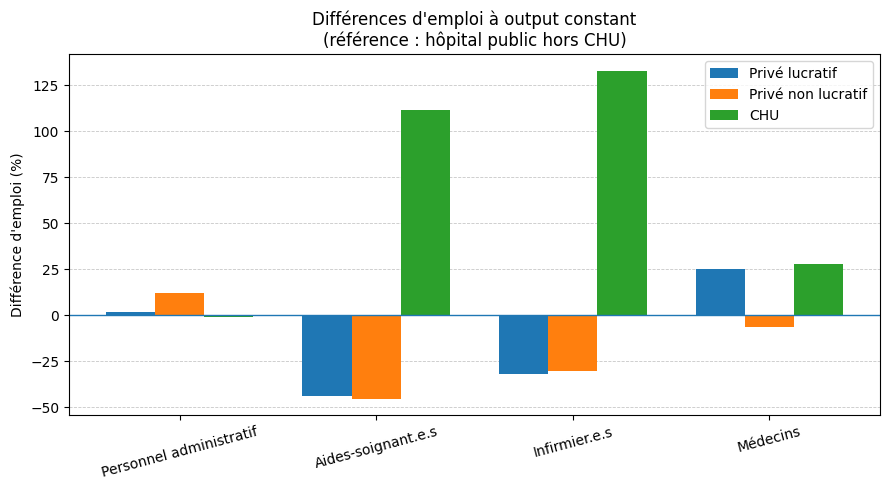

In [45]:
# Passage du dictionnaire à un DataFrame
df = pd.Series(dict_diff).unstack()

# On garde l'ordre souhaité
df = df.loc[["lADMIN", "lAID", "lIDE", "lMED"], ["PL", "PNL", "CHU"]]

# Renommage lisible
df.index = [
    "Personnel administratif",
    "Aides-soignant.e.s",
    "Infirmier.e.s",
    "Médecins"
]

df.columns = [
    "Privé lucratif",
    "Privé non lucratif",
    "CHU"
]

# Paramètres du graphique
x = np.arange(len(df.index))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

ax.yaxis.grid(True,linestyle="--",linewidth=0.6,alpha=0.7)
ax.set_axisbelow(True)

ax.bar(x - width, df["Privé lucratif"], width, label="Privé lucratif")
ax.bar(x, df["Privé non lucratif"], width, label="Privé non lucratif")
ax.bar(x + width, df["CHU"], width, label="CHU")



# Mise en forme
ax.set_ylabel("Différence d'emploi (%)")
ax.set_title(
    "Différences d'emploi à output constant\n"
    "(référence : hôpital public hors CHU)"
)
ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=15)
ax.legend()

ax.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

Evaluation des régression : R²

In [46]:
for inp, model in results.items():
    print(f"{inp} : R² = {model.rsquared:.3f} | R² ajusté = {model.rsquared_adj:.3f}")

lMED : R² = 0.817 | R² ajusté = 0.815
lIDE : R² = 0.765 | R² ajusté = 0.762
lAID : R² = 0.714 | R² ajusté = 0.710
lADMIN : R² = 0.725 | R² ajusté = 0.722


Concernant l'influence mesurée de la durée moyenne des séjours :

In [47]:
for inp, model in results.items():
    print(f"\n{inp}")
    print(model.params["lduree_MCO"])


lMED
-0.17637778685341027

lIDE
-0.06693529484507693

lAID
0.10929127087390049

lADMIN
-0.0704241009935396


Coefficients négatifs ? Très surprenant 

Effet de l'ambulatoire sur les différentes catégories de personnel :

In [48]:
for inp, model in results.items():
    print(f"{inp} : Hospitalisation complète : {model.params["lMCO_HC"]} | Hospitalisation partielle : {model.params["lMCO_HP"]}")

lMED : Hospitalisation complète : 0.2549154882344166 | Hospitalisation partielle : 0.08464277413726444
lIDE : Hospitalisation complète : 0.21380093432514333 | Hospitalisation partielle : 0.05904990659039858
lAID : Hospitalisation complète : 0.16872180286433452 | Hospitalisation partielle : 0.05227320225574967
lADMIN : Hospitalisation complète : 0.2062191754580347 | Hospitalisation partielle : 0.04276127672542894


Hospitalisation partielle -> moins demandante en personnel

Résultats complets des régressions :

In [49]:
results["lMED"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lMED   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     509.7
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:21:53   Log-Likelihood:                -3129.1
No. Observations:                3332   AIC:                             6336.
Df Residuals:                    3293   BIC:                             6575.
Df Model:                          38                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.6285      0.044     37.071      0.000       1.542       1.715
lURG             0.3083      0.056      5.466      0.000       0.198       0.419
lMCO_HP          0.0846      0.012      7.045      0.000       0.061       0.108
lMCO_HC          0.2549      0.019     13.207      0.000       0.217       0.293
lSSR             0.2940      0.024     12.365      0.000       0.247       0.341
lPSY             0.3935      0.030     13.293      0.000       0.335       0.452
lSEANCES         0.0610      0.015      3.952      0.000       0.031       0.091
lUSLD           -0.0153      0.039     -0.392      0.695      -0.092       0.061
Statut_PNL      -0.0662      0.061     -1.091      0.275      -0.185       0.053
Statut_PL        0.2242      0.066      3.391      0.001       0.095       0.354
Statut_CHU       0.2462      0.152      1.619      0.105      -0.052       0.544
I_PSY           -2.1860      0.250     -8.738      0.000      -2.676      -1.696
I_SSR           -1.5659      0.136    -11.482      0.000      -1.833      -1.299
I_URG           -2.6524      0.502     -5.279      0.000      -3.637      -1.668
I_USLD          -0.1219      0.129     -0.945      0.345      -0.375       0.131
I_SEANCES       -0.4591      0.097     -4.748      0.000      -0.649      -0.270
I_MCO           -0.4850      0.117     -4.149      0.000      -0.714      -0.256
lduree_MCO      -0.1764      0.046     -3.810      0.000      -0.267      -0.086
lURG_PNL        -0.0224      0.016     -1.438      0.151      -0.053       0.008
lMCO_HP_PNL      0.0293      0.019      1.573      0.116      -0.007       0.066
lMCO_HC_PNL      0.0103      0.016      0.636      0.525      -0.021       0.042
lSSR_PNL         0.0268      0.011      2.531      0.011       0.006       0.048
lPSY_PNL         0.0064      0.013      0.508      0.611      -0.018       0.031
lSEANCES_PNL     0.0436      0.015      2.863      0.004       0.014       0.074
lUSLD_PNL       -0.0002      0.026     -0.009      0.993      -0.052       0.051
lURG_PL         -0.0215      0.013     -1.693      0.090      -0.046       0.003
lMCO_HP_PL       0.0678      0.020      3.368      0.001       0.028       0.107
lMCO_HC_PL      -0.0535      0.021     -2.569      0.010      -0.094      -0.013
lSSR_PL         -0.0112      0.011     -1.066      0.286      -0.032       0.009
lPSY_PL         -0.0571      0.010     -5.522      0.000      -0.077      -0.037
lSEANCES_PL      0.0133      0.012      1.128      0.259      -0.010       0.037
lUSLD_PL         0.0166      0.034      0.484      0.629      -0.051       0.084
lURG_CHU        -0.0014      0.018     -0.079      0.937      -0.037       0.034
lMCO_HP_CHU      0.0783      0.029      2.712      0.007       0.022       0.135
lMCO_HC_CHU     -0.0546      0.030     -1.816      0.069      -0.114       0.004
lSSR_

In [50]:
results["lIDE"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lIDE   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     328.6
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:21:53   Log-Likelihood:                -3732.1
No. Observations:                3530   AIC:                             7542.
Df Residuals:                    3491   BIC:                             7783.
Df Model:                          38                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.5813      0.050     51.316      0.000       2.483       2.680
lURG             0.2939      0.068      4.332      0.000       0.161       0.427
lMCO_HP          0.0590      0.012      4.728      0.000       0.035       0.084
lMCO_HC          0.2138      0.021     10.157      0.000       0.173       0.255
lSSR             0.3297      0.028     11.972      0.000       0.276       0.384
lPSY             0.4853      0.032     15.225      0.000       0.423       0.548
lSEANCES         0.0883      0.019      4.597      0.000       0.051       0.126
lUSLD            0.1386      0.042      3.286      0.001       0.056       0.221
Statut_PNL      -0.3591      0.068     -5.259      0.000      -0.493      -0.225
Statut_PL       -0.3833      0.074     -5.205      0.000      -0.528      -0.239
Statut_CHU       0.8462      0.189      4.468      0.000       0.475       1.217
I_PSY           -2.4351      0.265     -9.195      0.000      -2.954      -1.916
I_SSR           -1.7474      0.157    -11.166      0.000      -2.054      -1.441
I_URG           -2.3426      0.592     -3.959      0.000      -3.502      -1.183
I_USLD          -0.3316      0.139     -2.382      0.017      -0.605      -0.059
I_SEANCES       -0.5589      0.110     -5.090      0.000      -0.774      -0.344
I_MCO           -0.7801      0.131     -5.937      0.000      -1.038      -0.523
lduree_MCO      -0.0669      0.042     -1.583      0.113      -0.150       0.016
lURG_PNL        -0.0184      0.018     -1.016      0.310      -0.054       0.017
lMCO_HP_PNL      0.0203      0.022      0.938      0.348      -0.022       0.063
lMCO_HC_PNL      0.0434      0.017      2.549      0.011       0.010       0.077
lSSR_PNL         0.0574      0.012      4.898      0.000       0.034       0.080
lPSY_PNL         0.0182      0.017      1.087      0.277      -0.015       0.051
lSEANCES_PNL     0.0298      0.018      1.655      0.098      -0.005       0.065
lUSLD_PNL       -0.0217      0.027     -0.811      0.417      -0.074       0.031
lURG_PL         -0.0172      0.015     -1.110      0.267      -0.047       0.013
lMCO_HP_PL       0.0588      0.019      3.042      0.002       0.021       0.097
lMCO_HC_PL      -0.0254      0.018     -1.413      0.158      -0.061       0.010
lSSR_PL          0.0344      0.011      3.007      0.003       0.012       0.057
lPSY_PL         -0.0529      0.012     -4.567      0.000      -0.076      -0.030
lSEANCES_PL      0.0281      0.014      1.956      0.050    -5.2e-05       0.056
lUSLD_PL         0.0111      0.031      0.363      0.717      -0.049       0.071
lURG_CHU        -0.0121      0.020     -0.605      0.545      -0.051       0.027
lMCO_HP_CHU      0.0538      0.029      1.863      0.062      -0.003       0.110
lMCO_HC_CHU     -0.0484      0.030     -1.615      0.106      -0.107       0.010
lSSR_

In [51]:
results["lAID"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lAID   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     254.3
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:21:53   Log-Likelihood:                -3327.6
No. Observations:                3141   AIC:                             6733.
Df Residuals:                    3102   BIC:                             6969.
Df Model:                          38                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.6701      0.054     49.781      0.000       2.565       2.775
lURG             0.3943      0.063      6.262      0.000       0.271       0.518
lMCO_HP          0.0523      0.014      3.806      0.000       0.025       0.079
lMCO_HC          0.1687      0.023      7.298      0.000       0.123       0.214
lSSR             0.3374      0.029     11.796      0.000       0.281       0.393
lPSY             0.3023      0.033      9.148      0.000       0.238       0.367
lSEANCES         0.0791      0.018      4.289      0.000       0.043       0.115
lUSLD            0.1654      0.044      3.755      0.000       0.079       0.252
Statut_PNL      -0.6034      0.079     -7.620      0.000      -0.759      -0.448
Statut_PL       -0.5796      0.080     -7.238      0.000      -0.736      -0.423
Statut_CHU       0.7509      0.231      3.254      0.001       0.299       1.203
I_PSY           -1.7802      0.282     -6.317      0.000      -2.333      -1.228
I_SSR           -1.5612      0.164     -9.521      0.000      -1.883      -1.240
I_URG           -3.2792      0.549     -5.969      0.000      -4.356      -2.202
I_USLD          -0.0225      0.144     -0.156      0.876      -0.305       0.260
I_SEANCES       -0.5069      0.110     -4.588      0.000      -0.723      -0.290
I_MCO           -1.0450      0.156     -6.710      0.000      -1.350      -0.740
lduree_MCO       0.1093      0.046      2.359      0.018       0.018       0.200
lURG_PNL        -0.0148      0.018     -0.830      0.407      -0.050       0.020
lMCO_HP_PNL      0.0150      0.024      0.620      0.535      -0.032       0.062
lMCO_HC_PNL      0.0439      0.019      2.267      0.023       0.006       0.082
lSSR_PNL         0.0766      0.013      5.814      0.000       0.051       0.102
lPSY_PNL         0.0415      0.020      2.054      0.040       0.002       0.081
lSEANCES_PNL     0.0226      0.016      1.375      0.169      -0.010       0.055
lUSLD_PNL        0.0528      0.032      1.658      0.097      -0.010       0.115
lURG_PL         -0.0085      0.015     -0.552      0.581      -0.038       0.022
lMCO_HP_PL       0.0080      0.023      0.344      0.731      -0.037       0.053
lMCO_HC_PL       0.0016      0.022      0.073      0.942      -0.041       0.045
lSSR_PL          0.0412      0.012      3.372      0.001       0.017       0.065
lPSY_PL         -0.0274      0.012     -2.299      0.022      -0.051      -0.004
lSEANCES_PL      0.0341      0.014      2.431      0.015       0.007       0.062
lUSLD_PL         0.0617      0.036      1.702      0.089      -0.009       0.133
lURG_CHU        -0.0232      0.020     -1.148      0.251      -0.063       0.016
lMCO_HP_CHU      0.0750      0.031      2.414      0.016       0.014       0.136
lMCO_HC_CHU     -0.0542      0.034     -1.606      0.108      -0.120       0.012
lSSR_

In [52]:
results["lADMIN"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lADMIN   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     276.1
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:21:53   Log-Likelihood:                -3490.9
No. Observations:                3389   AIC:                             7060.
Df Residuals:                    3350   BIC:                             7299.
Df Model:                          38                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.8619      0.056     33.537      0.000       1.753       1.971
lURG             0.2752      0.062      4.414      0.000       0.153       0.397
lMCO_HP          0.0428      0.014      3.166      0.002       0.016       0.069
lMCO_HC          0.2062      0.022      9.499      0.000       0.164       0.249
lSSR             0.2310      0.027      8.581      0.000       0.178       0.284
lPSY             0.3956      0.031     12.929      0.000       0.336       0.456
lSEANCES         0.1080      0.018      5.987      0.000       0.073       0.143
lUSLD           -0.0085      0.049     -0.173      0.863      -0.105       0.088
Statut_PNL       0.1156      0.072      1.605      0.108      -0.026       0.257
Statut_PL        0.0201      0.067      0.299      0.765      -0.112       0.152
Statut_CHU      -0.0075      0.238     -0.032      0.975      -0.474       0.459
I_PSY           -2.1405      0.254     -8.423      0.000      -2.639      -1.642
I_SSR           -1.1090      0.153     -7.270      0.000      -1.408      -0.810
I_URG           -2.1342      0.542     -3.935      0.000      -3.197      -1.071
I_USLD          -0.0368      0.162     -0.226      0.821      -0.355       0.282
I_SEANCES       -0.6546      0.104     -6.273      0.000      -0.859      -0.450
I_MCO           -0.4659      0.123     -3.781      0.000      -0.707      -0.224
lduree_MCO      -0.0704      0.043     -1.639      0.101      -0.155       0.014
lURG_PNL        -0.0312      0.018     -1.689      0.091      -0.067       0.005
lMCO_HP_PNL      0.0520      0.021      2.471      0.013       0.011       0.093
lMCO_HC_PNL     -0.0361      0.016     -2.232      0.026      -0.068      -0.004
lSSR_PNL         0.0630      0.012      5.043      0.000       0.039       0.088
lPSY_PNL         0.0173      0.015      1.167      0.243      -0.012       0.046
lSEANCES_PNL     0.0543      0.018      3.025      0.002       0.019       0.089
lUSLD_PNL       -0.0230      0.029     -0.783      0.434      -0.081       0.035
lURG_PL         -0.0298      0.015     -2.004      0.045      -0.059      -0.001
lMCO_HP_PL       0.0476      0.018      2.587      0.010       0.012       0.084
lMCO_HC_PL      -0.0638      0.018     -3.591      0.000      -0.099      -0.029
lSSR_PL          0.0137      0.011      1.252      0.210      -0.008       0.035
lPSY_PL         -0.0718      0.010     -6.994      0.000      -0.092      -0.052
lSEANCES_PL      0.0009      0.013      0.068      0.946      -0.025       0.027
lUSLD_PL         0.0221      0.043      0.516      0.606      -0.062       0.106
lURG_CHU        -0.0011      0.021     -0.051      0.959      -0.041       0.039
lMCO_HP_CHU      0.1288      0.041      3.147      0.002       0.049       0.209
lMCO_HC_CHU     -0.0784      0.044     -1.764      0.078      -0.165       0.009
lSSR_

Dans tous les cas, on constate que les coefficients associés au statut (PL,PNL ou CHU) affichent une forte significativité statistique, ce qui vient donner une certaine robustesse aux resultats. Voyons tout de même si l'on trouve des résultats identiques en procédant à des régressions séparées.

### 5 - Analyse contrefactuelle

Calcul de profils d'output de référence par catégorie : 

In [53]:
# =========================
# 1. Définition des outputs
# =========================
outputs = ["lMCO_HC","lMCO_HP","lPSY","lURG","lUSLD","lSSR","lSEANCES"]

# =========================
# 2. Construction variable Statut
# =========================
def get_statut(row):
    if row["Statut_CHU"] == 1:
        return "CHU"
    elif row["Statut_PL"] == 1:
        return "PL"
    elif row["Statut_PNL"] == 1:
        return "PNL"
    else:
        return "PHP"  # public non CHU

Data["Statut"] = Data.apply(get_statut, axis=1)

# =========================
# 3. Moyennes des log(outputs) par statut
# =========================
mean_outputs_by_statut = Data.groupby("Statut")[outputs].mean()

print("\n=== Moyennes des log(outputs) par statut ===")
print(mean_outputs_by_statut)

# =========================
# 4. Moyenne globale
# =========================
mean_outputs_global = Data[outputs].mean()

print("\n=== Moyenne globale des log(outputs) ===")
print(mean_outputs_global)

# =========================
# 5. Conversion en dictionnaires
# =========================
mean_outputs_dict = mean_outputs_by_statut.to_dict(orient="index")
mean_outputs_global_dict = mean_outputs_global.to_dict()

# Exemple d'accès :
# mean_outputs_dict["CHU"]["lMCO_HC"]

# =========================
# 6. Quantiles (profils alternatifs)
# =========================
quantiles = Data[outputs].quantile([0.25, 0.5, 0.75])

print("\n=== Quantiles des log(outputs) ===")
print(quantiles)

# Option : convertir en dictionnaire
quantiles_dict = {
    "q25": quantiles.loc[0.25].to_dict(),
    "q50": quantiles.loc[0.5].to_dict(),
    "q75": quantiles.loc[0.75].to_dict()
}

# =========================
# 7. (Optionnel) Vérification tailles groupes
# =========================
print("\n=== Nombre d'établissements par statut ===")
print(Data["Statut"].value_counts())


=== Moyennes des log(outputs) par statut ===
         lMCO_HC   lMCO_HP      lPSY      lURG     lUSLD      lSSR  lSEANCES
Statut                                                                      
CHU     6.375331  5.894180  1.759748  4.163717  0.769421  2.873789  4.092879
PHP     3.936476  2.585979  1.585747  3.007538  1.125100  3.345564  1.735285
PL      2.777120  3.005545  0.944497  0.970162  0.036675  2.213529  1.299974
PNL     1.067368  0.905152  0.465153  0.282591  0.133706  1.969204  0.492039

=== Moyenne globale des log(outputs) ===
lMCO_HC     2.819610
lMCO_HP     2.371031
lPSY        1.050729
lURG        1.595097
lUSLD       0.463019
lSSR        2.545757
lSEANCES    1.339108
dtype: float64

=== Quantiles des log(outputs) ===
       lMCO_HC   lMCO_HP  lPSY  lURG  lUSLD      lSSR  lSEANCES
0.25  0.000000  0.000000   0.0   0.0    0.0  0.000000       0.0
0.50  0.000000  0.000000   0.0   0.0    0.0  0.000000       0.0
0.75  6.986795  6.647034   0.0   0.0    0.0  5.834811       

Pour OLS :

In [92]:
# =========================
# 1. Variables
# =========================
inputs = ["lMED","lIDE","lAID","lADMIN"]
outputs = ["lMCO_HC","lMCO_HP","lPSY","lURG","lUSLD","lSSR","lSEANCES"]
statuts = ["PL","PNL","CHU"]  # PHP = référence

# =========================
# 2. Fonction effet + SE (OLS)
# =========================
def compute_effect_ols(res, statut, profile):
    params = res.params
    cov = res.cov_params()  # <-- spécifique OLS
    
    coefs = []
    weights = []
    
    # --- effet statut (gamma)
    gamma = f"Statut_{statut}"
    if gamma in params.index:
        coefs.append(gamma)
        weights.append(1.0)
    
    # --- interactions
    for out in outputs:
        var = f"{out}_{statut}"
        if var in params.index:
            coefs.append(var)
            weights.append(profile[out])
    
    # cas référence (PHP)
    if len(coefs) == 0:
        return 0.0, 0.0, 1.0
    
    weights = np.array(weights)
    beta = params[coefs].values
    sub_cov = cov.loc[coefs, coefs].values
    
    # --- effet
    delta = weights @ beta
    
    # --- variance
    var_delta = weights @ sub_cov @ weights
    se = np.sqrt(var_delta)
    
    # --- statistique
    t_stat = delta / se if se > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    return delta, se, p_value

# =========================
# 3. Profils d'activité
# =========================
profiles = {
    "global_mean": mean_outputs_global_dict,
    "q25": quantiles_dict["q25"],
    "q50": quantiles_dict["q50"],
    "q75": quantiles_dict["q75"]
}

# =========================
# 4. Calcul des effets OLS
# =========================
rows = []

for p in inputs:
    res = results[p]  # <-- dictionnaire OLS
    
    for profile_name, profile in profiles.items():
        for statut in statuts:
            
            delta, se, pval = compute_effect_ols(res, statut, profile)
            
            rows.append({
                "Personnel": p,
                "Statut": statut,
                "Profil": profile_name,
                "Effet_log": delta,
                "SE": se,
                "p_value": pval,
                "Effet_%": (np.exp(delta) - 1) * 100
            })

# =========================
# 5. Résultat
# =========================
effects_ols_df = pd.DataFrame(rows)

print("\n=== Différence de demande en personnel par rapport à un établissement public non CHU à outputs constants ===")
print(effects_ols_df.head())

# =========================
# 6. Pivot (lecture)
# =========================
pivot_ols = effects_ols_df.pivot_table(
    index=["Personnel","Statut"],
    columns="Profil",
    values="Effet_%"
)

print("\n=== Différence de demande en personnel par rapport à un établissement public non CHU (%) par profil ===")
print(pivot_ols)


=== Différence de demande en personnel par rapport à un établissement public non CHU à outputs constants ===
  Personnel Statut       Profil  Effet_log        SE   p_value    Effet_%
0      lMED     PL  global_mean   0.136912  0.038319  0.000353  14.672741
1      lMED    PNL  global_mean   0.130055  0.037288  0.000487  13.889138
2      lMED    CHU  global_mean   0.305655  0.095142  0.001315  35.751334
3      lMED     PL          q25   0.224210  0.066122  0.000697  25.133359
4      lMED    PNL          q25  -0.066186  0.060692  0.275485  -6.404279

=== Différence de demande en personnel par rapport à un établissement public non CHU (%) par profil ===
Profil            global_mean         q25         q50         q75
Personnel Statut                                                 
lADMIN    CHU        2.514937   -0.747940   -0.747940   22.153419
          PL       -11.626310    2.030019    2.030019   -2.877033
          PNL       38.823039   12.256078   12.256078   78.042716
lAID      C

Pour 2SLS :

In [91]:
# =========================
# 1. Inputs / outputs
# =========================
inputs = ["lMED","lIDE","lAID","lADMIN"]
outputs = ["lMCO_HC","lMCO_HP","lPSY","lURG","lUSLD","lSSR","lSEANCES"]

statuts = ["PL","PNL","CHU"]  # PHP = référence

# =========================
# 2. Fonction effet + SE
# =========================
def compute_effect(res, statut, profile):
    params = res.params
    cov = res.cov
    
    coefs = []
    weights = []
    
    # --- coefficient statut (gamma)
    gamma = f"Statut_{statut}"
    if gamma in params:
        coefs.append(gamma)
        weights.append(1.0)
    
    # --- interactions (theta)
    for out in outputs:
        var = f"{out}_{statut}"
        if var in params:
            coefs.append(var)
            weights.append(profile[out])
    
    if len(coefs) == 0:
        return 0, 0, 1  # statut de référence
    
    weights = np.array(weights)
    beta = params[coefs].values
    sub_cov = cov.loc[coefs, coefs].values
    
    # --- effet
    delta = weights @ beta
    
    # --- variance
    var_delta = weights @ sub_cov @ weights
    se = np.sqrt(var_delta)
    
    # --- stats
    t_stat = delta / se if se > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    return delta, se, p_value

# =========================
# 3. Profils d'activité
# =========================
profiles = {
    "global_mean": mean_outputs_global_dict,
    "q25": quantiles_dict["q25"],
    "q50": quantiles_dict["q50"],
    "q75": quantiles_dict["q75"]
}

# =========================
# 4. Calcul des effets
# =========================
rows = []

for p in inputs:
    res = result_instr[p]
    
    for profile_name, profile in profiles.items():
        for statut in statuts:
            
            delta, se, pval = compute_effect(res, statut, profile)
            
            rows.append({
                "Personnel": p,
                "Statut": statut,
                "Profil": profile_name,
                "Effet_log": delta,
                "SE": se,
                "p_value": pval,
                "Effet_%": (np.exp(delta) - 1) * 100
            })

# =========================
# 5. DataFrame final
# =========================
effects_df = pd.DataFrame(rows)

print("\n=== Différence de demande en personnel par rapport à un établissement public non CHU à outputs constants ===")
print(effects_df.head())

# =========================
# 6. Pivot (lecture facile)
# =========================
pivot_table = effects_df.pivot_table(
    index=["Personnel","Statut"],
    columns="Profil",
    values="Effet_%"
)

print("\n=== Différence de demande en personnel par rapport à un établissement public non CHU (%) par profil ===")
print(pivot_table)


=== Différence de demande en personnel par rapport à un établissement public non CHU à outputs constants ===
  Personnel Statut       Profil  Effet_log        SE   p_value    Effet_%
0      lMED     PL  global_mean   0.101683  0.048951  0.037780  10.703209
1      lMED    PNL  global_mean   0.174319  0.044635  0.000094  19.043479
2      lMED    CHU  global_mean   0.484939  0.109233  0.000009  62.407562
3      lMED     PL          q25   0.141712  0.078642  0.071549  15.224423
4      lMED    PNL          q25   0.047527  0.076602  0.534968   4.867476

=== Différence de demande en personnel par rapport à un établissement public non CHU (%) par profil ===
Profil            global_mean         q25         q50         q75
Personnel Statut                                                 
lADMIN    CHU       19.738929   29.165573   29.165573   14.741428
          PL       -17.045081   -2.702962   -2.702962  -16.247724
          PNL       41.791747   19.571616   19.571616   44.494514
lAID      C

### 6 - Analyse causale par variables instrumentales

Utilisation des données de 2019 comme instruments

#### 6.1 - Préparation des données

Extraction des données :

In [54]:
SYGEN2019 = pd.read_csv("SAE/2019/SYGEN_2019.csv", sep=";", encoding="latin-1")
Data2019 = SYGEN2019[['FI','FI_EJ','EFFSAL_TOT','EFFLIB_TOT','EFF_INFSANSSPE','EFF_INFAVECSPE','EFF_AID','EFF_DIR','EFF_AUTADM','SEJHC_SSR','SEJHC_MCO','SEJHP_MCO','SEJ_HTP_TOT','VEN_HDJ_TOT','VEN_HDN_TOT','SEAN_HEMO_CENTRE','SEAN_CHIMIO','SEAN_RADIO']]
Data2019 = Data2019.merge(FINESS, on="FI", how="left")

In [55]:
Urg2019 = pd.read_csv("SAE/2019/URGENCES2_2019.csv", sep=";", encoding="latin-1")
Urg2019 = Urg2019[['FI','PASSU']]
Urg2019 = Urg2019.groupby("FI").sum().reset_index()
Data2019 = Data2019.merge(Urg2019, on="FI", how="left")

In [56]:
USLD2019 = pd.read_csv("SAE/2019/USLD_2019.csv", sep=";", encoding="latin-1")
USLD2019 = USLD2019[['FI','ENT']]
Data2019 = Data2019.merge(USLD2019, on="FI", how="left")

Catégorie de personnel (Inputs) :

In [57]:
Data2019['EFF_MED'] = Data2019['EFFSAL_TOT'] + Data2019['EFFLIB_TOT'].fillna(0)
Data2019['EFF_IDE'] = Data2019['EFF_INFSANSSPE'] + Data2019['EFF_INFAVECSPE'].fillna(0)
Data2019['EFF_ADMIN'] = Data2019['EFF_AUTADM'] + Data2019['EFF_DIR'].fillna(0)

Outputs :

In [58]:
Data2019['PSY'] = Data2019['SEJ_HTP_TOT'] + Data2019['VEN_HDJ_TOT'].fillna(0) + Data2019['VEN_HDN_TOT'].fillna(0)
Data2019['PSY'] = Data2019['PSY'].fillna(0)
Data2019['I_PSY_2019'] = (Data2019['PSY'] > 0).astype(int)

Data2019['MCO'] = Data2019['SEJHP_MCO'] + Data2019['SEJHC_MCO']
Data2019['MCO'] = Data2019['MCO'].fillna(0)
Data2019['I_MCO_2019'] = (Data2019['MCO'] > 0).astype(int)

Data2019['SEANCES'] = Data2019['SEAN_HEMO_CENTRE'].fillna(0) + Data2019['SEAN_CHIMIO'] + Data2019['SEAN_RADIO'].fillna(0)
Data2019['SEANCES'] = Data2019['SEANCES'].fillna(0)
Data2019['I_SEANCES_2019'] = (Data2019['SEANCES'] > 0).astype(int)

Data2019['PASSU'] = Data2019['PASSU'].fillna(0)
Data2019['I_URG_2019'] = (Data2019['PASSU'] > 0).astype(int)

Data2019['ENT'] = Data2019['ENT'].fillna(0)
Data2019['I_USLD_2019'] = (Data2019['ENT'] > 0).astype(int)

Data2019['SEJHC_SSR'] = Data2019['SEJHC_SSR'].fillna(0)
Data2019['I_SSR_2019'] = (Data2019['SEJHC_SSR'] > 0).astype(int)

Passage au log :

In [59]:
Data2019['lURG_2019'] = np.log(Data2019['PASSU']+1)
Data2019['lMCO_HC_2019'] = np.log(SYGEN2019['SEJHC_MCO'].fillna(0)+1)
Data2019['lMCO_HP_2019'] = np.log(SYGEN2019['SEJHP_MCO'].fillna(0)+1)
Data2019['lPSY_2019'] = np.log(Data2019['PSY']+1)
Data2019['lSSR_2019'] = np.log(Data2019['SEJHC_SSR']+1)
Data2019['lSEANCES_2019'] = np.log(Data2019['SEANCES']+1)
Data2019['lUSLD_2019'] = np.log(Data2019['ENT']+1)

Data2019['lMED_2019'] = np.log(Data2019['EFF_MED']+1)
Data2019['lIDE_2019'] = np.log(Data2019['EFF_IDE']+1)
Data2019['lAID_2019'] = np.log(Data2019['EFF_AID']+1)
Data2019['lADMIN_2019'] = np.log(Data2019['EFF_ADMIN']+1)

Indicatrices de statut :

In [60]:
dummies_2019 = pd.get_dummies(Data2019['Statut'], prefix='Statut')

Data2019['Statut_PNL_2019'] = dummies_2019['Statut_Privé non lucratif']
Data2019['Statut_PL_2019']  = dummies_2019['Statut_Privé lucratif']
Data2019['Statut_CHU_2019'] = dummies_2019['Statut_CHU']

Data2019['Statut_PNL_2019'] = Data2019['Statut_PNL_2019'].astype(int)
Data2019['Statut_PL_2019']  = Data2019['Statut_PL_2019'].astype(int)
Data2019['Statut_CHU_2019'] = Data2019['Statut_CHU_2019'].astype(int)

Hospidiag :

In [61]:
A9_imputed_2019 = pd.read_csv("A9_imputed2019.csv", sep=",", decimal = ".", encoding="utf-8")
Data2019 = Data2019.merge(A9_imputed_2019, on="FI", how="left")

Durée séjours MCO :

In [62]:
dureeMCO_2019 = SYGEN2019['JOU_MCO']/SYGEN2019['SEJHC_MCO']
Data2019["duree_MCO_2019"] = dureeMCO_2019.fillna(0)
Data2019["lduree_MCO_2019"] = np.log(Data2019["duree_MCO_2019"]+1)

Interactions :

In [63]:
for var in ["lURG_2019", "lMCO_HC_2019","lMCO_HP_2019", "lSSR_2019", "lPSY_2019","lSEANCES_2019", "lUSLD_2019"]:
    Data2019[f"{var}_PNL"] = Data2019[var] * Data2019["Statut_PNL_2019"]
    Data2019[f"{var}_PL"]  = Data2019[var] * Data2019["Statut_PL_2019"]
    Data2019[f"{var}_CHU"]  = Data2019[var] * Data2019["Statut_CHU_2019"]

categorisation des variables :

In [64]:
inputs_2019 = ["lMED_2019","lIDE_2019","lAID_2019","lADMIN_2019"]
outputs_2019 = ["lURG_2019", "lMCO_HC_2019","lMCO_HP_2019", "lSSR_2019", "lPSY_2019","lSEANCES_2019", "lUSLD_2019"]
controles_statut_2019 = ["Statut_PNL_2019", "Statut_PL_2019","Statut_CHU_2019"]
controles_services_2019 = ["I_PSY_2019", "I_SSR_2019", "I_URG_2019", "I_USLD_2019","I_SEANCES_2019", "I_MCO_2019"]
controles_autres_2019= ["lduree_MCO_2019"]
interactions_statut_2019 = [f"{var}_PNL" for var in outputs_2019] + [f"{var}_PL" for var in outputs_2019] + [f"{var}_CHU" for var in outputs_2019]
controles_hospidiag_2019 = ["A9_imp_2019"]

Données utiles :

In [65]:
Data_instr = Data[['FI'] + inputs + outputs + controles_statut + controles_services + controles_autres + interactions_statut + controles_hospidiag]
Data_instr = Data_instr.merge(Data2019[['FI']+inputs_2019 + outputs_2019 + controles_statut_2019 + controles_services_2019 + controles_autres_2019 + interactions_statut_2019 + controles_hospidiag_2019], on="FI", how="inner")
print(Data_instr.shape) 

(3824, 87)


#### 6.2 - Vérification de la pertinence des instruments

Analyse des corrélations entre les variables de 2022 et leurs équivalents de 2019 :

In [66]:
for var in outputs + ['lduree_MCO']:
    corr = Data_instr[var].corr(Data_instr[f"{var}_2019"])
    print(var, round(corr,3))

lMCO_HC 0.991
lMCO_HP 0.98
lPSY 0.982
lURG 0.989
lUSLD 0.966
lSSR 0.978
lSEANCES 0.947
lduree_MCO 0.973


On observe une corrélation proche de 1 (>0.95), pour chacun des outputs considérés, entre 2019 et 2022, d'où la pertinence d'utiliser les outputs de 2019 comme instruments.

In [67]:
for i in range(len(interactions_statut)):
    var = interactions_statut[i]
    var_2019 = interactions_statut_2019[i]
    corr = Data_instr[var].corr(Data_instr[var_2019])
    print(var, round(corr,3))

lURG_PNL 0.954
lMCO_HP_PNL 0.899
lMCO_HC_PNL 0.883
lSSR_PNL 0.995
lPSY_PNL 0.956
lSEANCES_PNL 0.901
lUSLD_PNL 0.961
lURG_PL 0.99
lMCO_HP_PL 0.948
lMCO_HC_PL 0.946
lSSR_PL 0.988
lPSY_PL 0.989
lSEANCES_PL 0.938
lUSLD_PL 0.969
lURG_CHU 0.994
lMCO_HP_CHU 0.953
lMCO_HC_CHU 0.948
lSSR_CHU 0.971
lPSY_CHU 0.978
lSEANCES_CHU 0.977
lUSLD_CHU 0.945


De façon cohérente, on retrouve une forte corrélation sur les termes d'interaction que l'on va également instrumenter.

In [68]:
Data_instr.columns

Index(['FI', 'lMED', 'lIDE', 'lAID', 'lADMIN', 'lMCO_HC', 'lMCO_HP', 'lPSY',
       'lURG', 'lUSLD', 'lSSR', 'lSEANCES', 'Statut_PNL', 'Statut_PL',
       'Statut_CHU', 'I_PSY', 'I_SSR', 'I_URG', 'I_USLD', 'I_SEANCES', 'I_MCO',
       'lduree_MCO', 'lURG_PNL', 'lMCO_HP_PNL', 'lMCO_HC_PNL', 'lSSR_PNL',
       'lPSY_PNL', 'lSEANCES_PNL', 'lUSLD_PNL', 'lURG_PL', 'lMCO_HP_PL',
       'lMCO_HC_PL', 'lSSR_PL', 'lPSY_PL', 'lSEANCES_PL', 'lUSLD_PL',
       'lURG_CHU', 'lMCO_HP_CHU', 'lMCO_HC_CHU', 'lSSR_CHU', 'lPSY_CHU',
       'lSEANCES_CHU', 'lUSLD_CHU', 'A9_imp_2022', 'lMED_2019', 'lIDE_2019',
       'lAID_2019', 'lADMIN_2019', 'lURG_2019', 'lMCO_HC_2019', 'lMCO_HP_2019',
       'lSSR_2019', 'lPSY_2019', 'lSEANCES_2019', 'lUSLD_2019',
       'Statut_PNL_2019', 'Statut_PL_2019', 'Statut_CHU_2019', 'I_PSY_2019',
       'I_SSR_2019', 'I_URG_2019', 'I_USLD_2019', 'I_SEANCES_2019',
       'I_MCO_2019', 'lduree_MCO_2019', 'lURG_2019_PNL', 'lMCO_HC_2019_PNL',
       'lMCO_HP_2019_PNL', 'lSSR_2019_

In [69]:
Data_instr = Data_instr.dropna()
print(Data_instr.shape)

(2760, 87)


#### 6.3 - Estimations par la méthode des doubles moindres carrés

Estimations en instrumentant les outputs et les termes d'interaction associés :

In [70]:
endog_vars = outputs + interactions_statut + ['lduree_MCO']
instr_vars = outputs_2019 + interactions_statut_2019 + ['lduree_MCO_2019']
controles = controles_statut + controles_services

endog_str = " + ".join(endog_vars)
instr_str = " + ".join(instr_vars)
control_str = " + ".join(controles)

result_instr = {}

for inp in inputs:

    formula = f"""
    {inp} ~ 1
    + {control_str}
    + [{endog_str} ~ {instr_str}]
    """

    model = IV2SLS.from_formula(
        formula,
        data=Data_instr
    )

    res = model.fit(cov_type="robust")

    result_instr[inp] = res

#### 6.4 - Analyse des résultats

In [71]:
#Affichage des résultats des régressions avec variables instrumentales pour les Médecins

print("\n========================")
print("Résultat pour lMED")
print("========================")
print(result_instr['lMED'].summary)


Résultat pour lMED
                          IV-2SLS Estimation Summary                          
Dep. Variable:                   lMED   R-squared:                      0.8351
Estimator:                    IV-2SLS   Adj. R-squared:                 0.8328
No. Observations:                2760   F-statistic:                 1.705e+04
Date:                Sat, Apr 25 2026   P-value (F-stat)                0.0000
Time:                        14:21:54   Distribution:                 chi2(38)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        1.7335     0.0505     34.336     0.0000      1.6346      1.8325
Statut_PNL       0.0475 

In [72]:
#Affichage des résultats des régressions avec variables instrumentales pour les Infirmier.e.s

print("\n========================")
print("Résultat pour lIDE")
print("========================")
print(result_instr['lIDE'].summary)


Résultat pour lIDE
                          IV-2SLS Estimation Summary                          
Dep. Variable:                   lIDE   R-squared:                      0.7960
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7932
No. Observations:                2760   F-statistic:                 1.072e+04
Date:                Sat, Apr 25 2026   P-value (F-stat)                0.0000
Time:                        14:21:54   Distribution:                 chi2(38)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        2.8366     0.0538     52.742     0.0000      2.7312      2.9420
Statut_PNL      -0.1131 

In [73]:
#Affichage des résultats des régressions avec variables instrumentales pour les Aides-soignant.e.s

print("\n========================")
print("Résultat pour lAID")
print("========================")
print(result_instr['lAID'].summary)


Résultat pour lAID
                          IV-2SLS Estimation Summary                          
Dep. Variable:                   lAID   R-squared:                      0.7213
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7174
No. Observations:                2760   F-statistic:                    8234.3
Date:                Sat, Apr 25 2026   P-value (F-stat)                0.0000
Time:                        14:21:54   Distribution:                 chi2(38)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        2.8860     0.0555     52.040     0.0000      2.7773      2.9947
Statut_PNL      -0.5843 

In [74]:
#Affichage des résultats des régressions avec variables instrumentales pour le personnel administratif

print("\n========================")
print("Résultat pour lADMIN")
print("========================")
print(result_instr['lADMIN'].summary)


Résultat pour lADMIN
                          IV-2SLS Estimation Summary                          
Dep. Variable:                 lADMIN   R-squared:                      0.7487
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7451
No. Observations:                2760   F-statistic:                    9019.5
Date:                Sat, Apr 25 2026   P-value (F-stat)                0.0000
Time:                        14:21:54   Distribution:                 chi2(38)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        1.9964     0.0611     32.686     0.0000      1.8767      2.1161
Statut_PNL       0.178

Affichage de Fstats et des régressions de première étape :

In [75]:
result_instr["lMED"].first_stage

,lMCO_HC,lMCO_HP,lPSY,lURG,lUSLD,lSSR,lSEANCES,lURG_PNL,lMCO_HP_PNL,lMCO_HC_PNL,lSSR_PNL,lPSY_PNL,lSEANCES_PNL,lUSLD_PNL,lURG_PL,lMCO_HP_PL,lMCO_HC_PL,lSSR_PL,lPSY_PL,lSEANCES_PL,lUSLD_PL,lURG_CHU,lMCO_HP_CHU,lMCO_HC_CHU,lSSR_CHU,lPSY_CHU,lSEANCES_CHU,lUSLD_CHU,lduree_MCO
R-squared,0.9867,0.9623,0.9851,0.9967,0.9665,0.9793,0.9675,0.9288,0.9653,0.9933,0.9918,0.9521,0.8868,0.9277,0.9822,0.9784,0.9919,0.9793,0.9868,0.9212,0.9400,0.9883,0.9684,0.9924,0.9557,0.9620,0.9635,0.9058,0.9608
Partial R-squared,0.7855,0.8254,0.5183,0.3905,0.2596,0.3528,0.4929,0.9201,0.9517,0.9899,0.9785,0.9399,0.8549,0.9117,0.9735,0.9483,0.9799,0.9498,0.9793,0.8598,0.9369,0.9760,0.8506,0.9572,0.9017,0.9443,0.9171,0.8643,0.7178
Shea's R-squared,0.6274,0.6933,0.4771,0.1158,0.2369,0.2627,0.3070,0.6629,0.7122,0.8151,0.8589,0.8909,0.4596,0.8819,0.6403,0.7057,0.7595,0.8353,0.9194,0.4530,0.9234,0.4926,0.6232,0.7038,0.7982,0.8864,0.6519,0.8022,0.5528
Partial F-statistic,5031.7,9400.4,358.97,567.58,134.64,685.73,521.04,7775.8,4.533e+04,2.441e+05,1.507e+05,2.154e+04,4006.3,2254.8,1.334e+05,7.562e+04,3.612e+05,2.043e+05,4.419e+04,1.006e+04,1806.8,3.754e+05,5036.7,3.567e+04,1.676e+04,1.872e+04,1.739e+04,2079.5,4682.6
P-value (Partial F-stat),0.0000,0.0000,0.0000,0.0000,1.443e-15,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Partial F-stat Distn,chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29),chi2(29)
==========================,===========,===========,============,===========,===========,===========,===========,===========,===========,============,===========,===========,===========,===========,===========,==============,============,===========,============,===========,============,===========,===========,===========,===========,===========,============,============,===========
Intercept,-0.0138,-0.0319,0.0687,-0.0218,-0.0265,-0.0731,-0.0770,-0.0059,-0.0061,-0.0089,-0.0132,0.0115,-0.0154,-0.0083,-0.0094,-0.0185,-0.0069,-0.0624,0.0050,-0.0309,-0.0023,-0.0038,-0.0125,-0.0063,-0.0315,-0.0010,-0.0033,-0.0108,-0.0138
,(-0.4071),(-0.7442),(2.8313),(-1.0977),(-1.0339),(-2.5527),(-1.6384),(-0.6459),(-0.9151),(-1.5142),(-1.7911),(1.3468),(-1.2560),(-1.8905),(-1.3389),(-1.8425),(-1.0864),(-3.1916),(1.0833),(-1.1941),(-1.0569),(-0.9388),(-1.3648),(-1.0340),(-2.4451),(-0.1573),(-0.5151),(-1.7930),(-0.9515)
Statut_PNL,0.0291,0.0119,-0.0348,0.0044,-0.0042,0.0608,-0.0818,-0.0779,-0.0162,0.0266,0.0906,0.0114,-0.3104,-0.0054,0.0288,0.0116,0.0118,0.0381,-0.0029,0.1163,0.0019,0.0117,0.0161,0.0069,0.0213,0.0025,0.0210,0.0072,0.0032


On s'intéresse à la différence entre ambulatoire et hospitalisation complète. Calcul des elasticités, ecarts-types et p-valeurs associées.

In [76]:

HC, HP = "lMCO_HC", "lMCO_HP"

statuts = {
    "Public": None,
    "PL": "Statut_PL",
    "PNL": "Statut_PNL",
    "CHU": "Statut_CHU"
}

rows = []

for p in inputs:
    res = result_instr[p]
    
    for statut_name, statut_var in statuts.items():
        
        # --- HC ---
        beta_HC = res.params[HC]
        var_HC = res.cov.loc[HC, HC]
        
        if statut_var is not None:
            inter_HC = f"{HC}_{statut_var.split('_')[1]}"
            
            beta_HC += res.params.get(inter_HC, 0)
            
            var_HC += res.cov.loc[inter_HC, inter_HC] \
                      + 2 * res.cov.loc[HC, inter_HC]
        
        se_HC = np.sqrt(var_HC)
        t_HC = beta_HC / se_HC
        p_HC = 2 * (1 - stats.norm.cdf(abs(t_HC)))
        
        
        # --- HP ---
        beta_HP = res.params[HP]
        var_HP = res.cov.loc[HP, HP]
        
        if statut_var is not None:
            inter_HP = f"{HP}_{statut_var.split('_')[1]}"
            
            beta_HP += res.params.get(inter_HP, 0)
            
            var_HP += res.cov.loc[inter_HP, inter_HP] \
                      + 2 * res.cov.loc[HP, inter_HP]
        
        se_HP = np.sqrt(var_HP)
        t_HP = beta_HP / se_HP
        p_HP = 2 * (1 - stats.norm.cdf(abs(t_HP)))
        
        
        rows.append({
            "Personnel": p,
            "Statut": statut_name,
            "HC_coef": beta_HC,
            "HC_se": se_HC,
            "HC_pval": p_HC,
            "HP_coef": beta_HP,
            "HP_se": se_HP,
            "HP_pval": p_HP
        })

table_MCO = pd.DataFrame(rows)

In [77]:
print(table_MCO)

   Personnel  Statut   HC_coef     HC_se       HC_pval   HP_coef     HP_se  \
0       lMED  Public  0.275450  0.022090  0.000000e+00  0.071151  0.012312   
1       lMED      PL  0.194735  0.025000  6.661338e-15  0.161694  0.023048   
2       lMED     PNL  0.265232  0.022225  0.000000e+00  0.096076  0.019758   
3       lMED     CHU  0.180555  0.035267  3.061498e-07  0.168036  0.033489   
4       lIDE  Public  0.182816  0.023199  3.330669e-15  0.060650  0.012268   
5       lIDE      PL  0.151925  0.022619  1.857114e-11  0.086237  0.017642   
6       lIDE     PNL  0.212955  0.024262  0.000000e+00  0.054325  0.019673   
7       lIDE     CHU  0.133288  0.031947  3.017506e-05  0.090960  0.031425   
8       lAID  Public  0.163533  0.027401  2.400840e-09  0.033669  0.014538   
9       lAID      PL  0.136743  0.028721  1.925601e-06  0.056156  0.024741   
10      lAID     PNL  0.190156  0.027284  3.181899e-12  0.048970  0.021506   
11      lAID     CHU  0.111514  0.036630  2.331849e-03  0.128918

### 7 - Statistiques descriptives et graphiques

Etude des ratios de personnel médical par médecins :

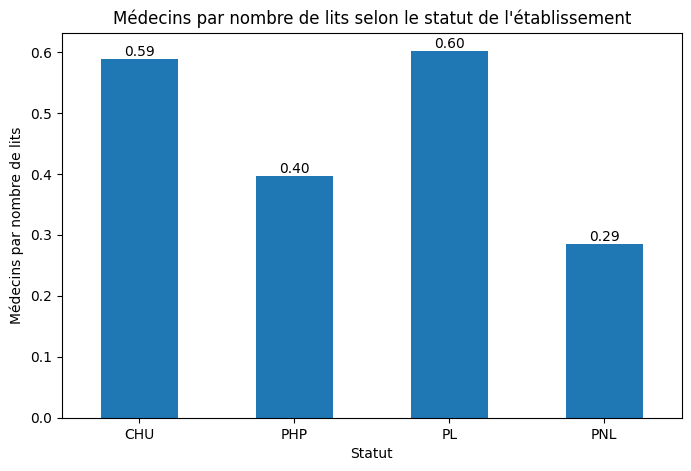

In [78]:
Data['lits'] = SYGEN2022['LIT_MCO'].fillna(0) + SYGEN2022['PLA_MED'].fillna(0) + SYGEN2022['LIT_SSR'].fillna(0) + SYGEN2022['LIT_USLD'].fillna(0)
Data_lits = Data[Data['lits'] > 0].copy()
Data_lits['ratio_med'] = Data_lits['EFF_MED'] / Data_lits['lits']
ax = Data_lits['ratio_med'].groupby(Data_lits["Statut"]).mean().plot(kind="bar", figsize=(8,5))
# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Médecins par nombre de lits")
plt.title("Médecins par nombre de lits selon le statut de l'établissement")
plt.xticks(rotation=0)
plt.show()

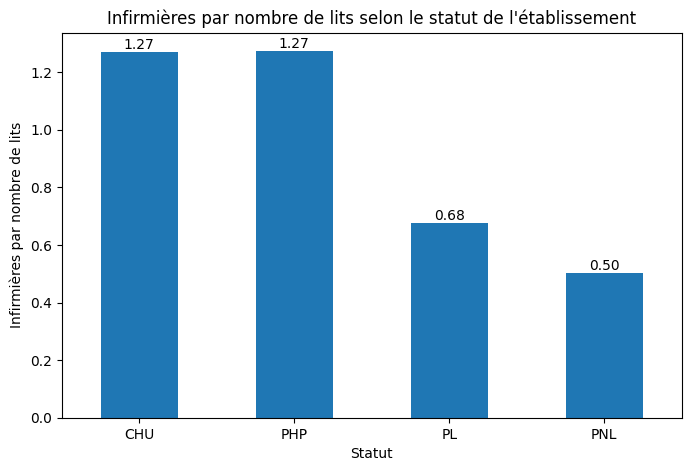

In [79]:
Data_lits['ratio_ide'] = Data_lits['EFF_IDE'] / Data_lits['lits']
ax = Data_lits['ratio_ide'].groupby(Data_lits["Statut"]).mean().plot(kind="bar", figsize=(8,5))
# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Infirmières par nombre de lits")
plt.title("Infirmières par nombre de lits selon le statut de l'établissement")
plt.xticks(rotation=0)
plt.show()

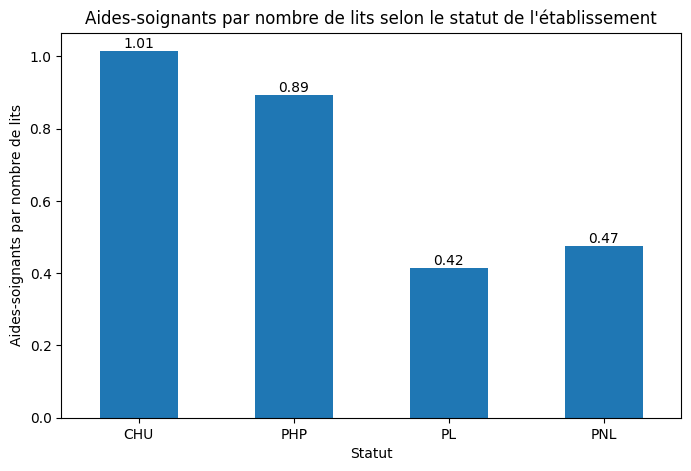

In [80]:
Data_lits['ratio_aid'] = Data_lits['EFF_AID'] / Data_lits['lits']
ax = Data_lits['ratio_aid'].groupby(Data_lits["Statut"]).mean().plot(kind="bar", figsize=(8,5))
# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Aides-soignants par nombre de lits")
plt.title("Aides-soignants par nombre de lits selon le statut de l'établissement")
plt.xticks(rotation=0)
plt.show()

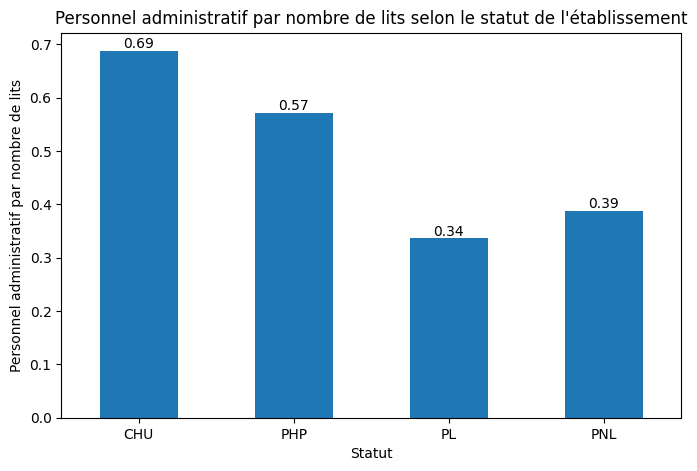

In [81]:
Data_lits['ratio_admin'] = Data_lits['EFF_ADMIN'] / Data_lits['lits']
ax = Data_lits['ratio_admin'].groupby(Data_lits["Statut"]).mean().plot(kind="bar", figsize=(8,5))
# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Personnel administratif par nombre de lits")
plt.title("Personnel administratif par nombre de lits selon le statut de l'établissement")
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_26537/3381737263.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_med['ratio_IDE'] = Data_med['EFF_IDE'] / Data_med['EFF_MED']


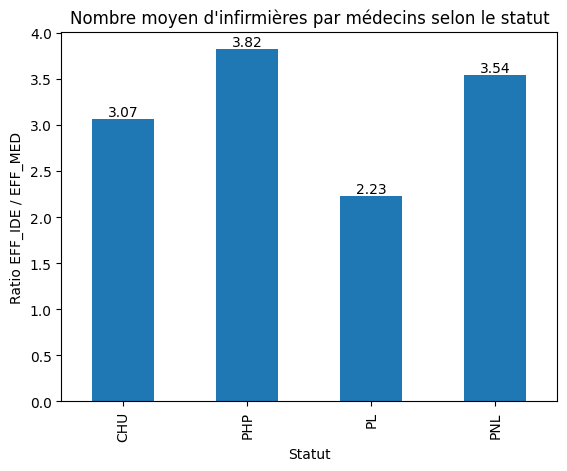

In [82]:
Data_med = Data[Data['EFF_MED'] > 0]
Data_med['ratio_IDE'] = Data_med['EFF_IDE'] / Data_med['EFF_MED']
ax = Data_med['ratio_IDE'].groupby(Data_med["Statut"]).mean().plot(kind="bar")

# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Ratio EFF_IDE / EFF_MED")
plt.title("Nombre moyen d'infirmières par médecins selon le statut")
plt.show()

/tmp/ipykernel_26537/2943411358.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_med['ratio_AID'] = Data_med['EFF_AID'] / Data_med['EFF_MED']


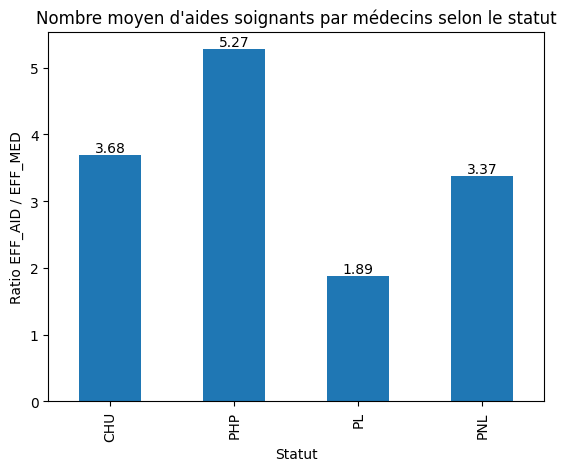

In [83]:
Data_med['ratio_AID'] = Data_med['EFF_AID'] / Data_med['EFF_MED']
ax = Data_med['ratio_AID'].groupby(Data_med["Statut"]).mean().plot(kind="bar")

# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Ratio EFF_AID / EFF_MED")
plt.title("Nombre moyen d'aides soignants par médecins selon le statut")
plt.show()

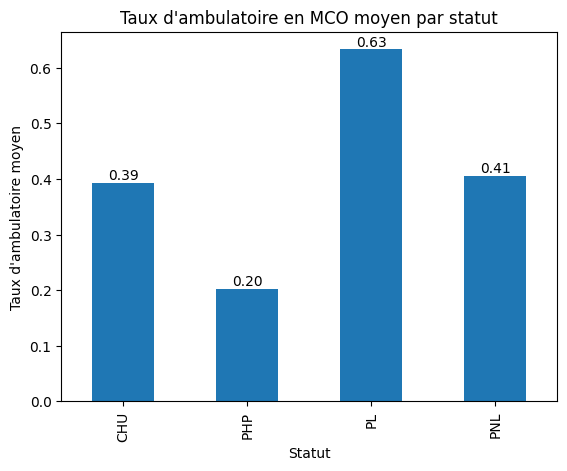

In [84]:
Data['taux_ambulatoire'] = Data['SEJHP_MCO'] / (Data['SEJHC_MCO'] + Data['SEJHP_MCO'])
ax = Data['taux_ambulatoire'].groupby(Data["Statut"]).mean().plot(kind="bar")

# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Taux d'ambulatoire moyen")
plt.title("Taux d'ambulatoire en MCO moyen par statut")
plt.show()

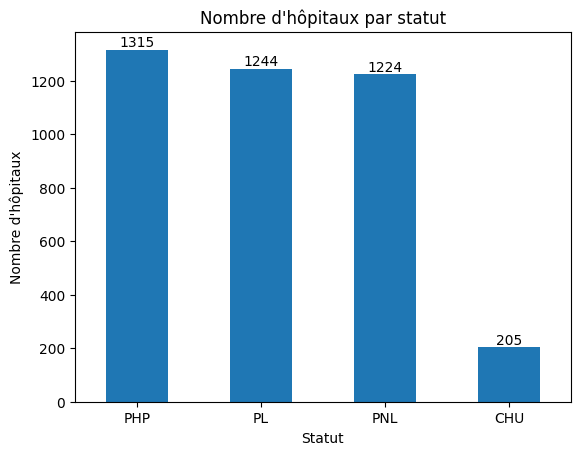

In [85]:
# Comptage des hôpitaux par statut
counts = Data["Statut"].value_counts()

# Graphique
ax = counts.plot(kind="bar")

# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Nombre d'hôpitaux")
plt.title("Nombre d'hôpitaux par statut")
plt.xticks(rotation=0)
plt.show()

In [86]:
vars_ratio = ["ratio_med","ratio_ide","ratio_aid","ratio_admin"]

table = Data_lits.groupby("Statut")[vars_ratio].mean().round(3)

In [87]:
table

,ratio_med,ratio_ide,ratio_aid,ratio_admin
Statut,,,,
CHU,0.588,1.269,1.015,0.687
PHP,0.396,1.273,0.893,0.572
PL,0.602,0.677,0.415,0.336
PNL,0.286,0.504,0.475,0.387
